# Advanced Investment Strategy — WTI Crude Oil Direction

This notebook combines four trained models (**MLP+EN**, **XGBoost**, **LSTM**, **VAR**) into three progressively sophisticated trading strategies, all evaluated net of transaction costs.

Building on `Investment_Strategy_VIP.ipynb`, this notebook introduces:
1. **Strategy 1** — Sharpe-Weighted Dynamic Ensemble: models that performed well recently get higher weight
2. **Strategy 2** — Volatility-Targeted Regime-Aware Strategy: scale position to target 15% annual vol; halve exposure during crisis regimes
3. **Strategy 3** — Mean-Variance Walk-Forward Portfolio Optimization: monthly re-optimization across all model signals using Markowitz theory

**Val period (2015–2024)** predictions serve as warm-up history for rolling windows. All performance metrics are reported on the **test set (2025+)** only.

## 1. Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy.optimize import minimize
from sklearn.metrics import accuracy_score
warnings.filterwarnings("ignore")

PRED_DIR   = Path("../predictions")
PRICE_FILE = Path("../data/price/Price.csv")
TC_COST    = 0.0005                          # 0.05% one-way transaction cost
MODELS     = ["mlpen", "xgb", "lstm", "var"]
LABELS     = {"mlpen": "MLP+EN", "xgb": "XGBoost", "lstm": "LSTM", "var": "VAR"}
VAL_END    = pd.Timestamp("2024-12-31")

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False})

## 2. Load Predictions & Price Returns

Each CSV contains columns `y_true`, `y_pred ∈ {+1, −1}`, and `prob = P(Up) ∈ [0, 1]`. All four models share the same val/test date index. Val predictions (2015–2024) are loaded solely as warm-up history for rolling strategies; all reported metrics and charts use the **test set (2025+)**.

In [2]:
def load_preds(tag, split):
    return pd.read_csv(PRED_DIR / f"{tag}_{split}_preds.csv",
                       index_col=0, parse_dates=True)

preds = {}
for m in MODELS:
    val  = load_preds(m, "val")
    test = load_preds(m, "test")
    preds[m] = pd.concat([val, test]).sort_index()

# Align all models to shared index (inner join)
common_idx = preds[MODELS[0]].index
for m in MODELS[1:]:
    common_idx = common_idx.intersection(preds[m].index)
for m in MODELS:
    preds[m] = preds[m].reindex(common_idx)

# Daily price returns
price = (pd.read_csv(PRICE_FILE, parse_dates=["Date"])
           .set_index("Date")["Price"].sort_index())
ret = price.pct_change().reindex(common_idx).rename("ret")

# Convenience DataFrames
prob_df = pd.DataFrame({m: preds[m]["prob"]   for m in MODELS}, index=common_idx)
pred_df = pd.DataFrame({m: preds[m]["y_pred"] for m in MODELS}, index=common_idx)
y_true  = preds[MODELS[0]]["y_true"]

test_mask = common_idx > VAL_END
val_mask  = common_idx <= VAL_END

print(f"Prediction period : {common_idx[0].date()} → {common_idx[-1].date()}")
print(f"Val rows          : {val_mask.sum()}")
print(f"Test rows         : {test_mask.sum()}")
print(f"\nModel accuracy on test set:")
for m in MODELS:
    acc = accuracy_score(preds[m]["y_true"][test_mask], preds[m]["y_pred"][test_mask])
    print(f"  {LABELS[m]:<12s}: {acc:.4f}")

print(f"\nDays all 4 models agree (test): "
      f"{(pred_df[test_mask].abs().sum(axis=1) == 4).mean():.1%}")

Prediction period : 2015-01-01 → 2025-10-31
Val rows          : 2635
Test rows         : 216

Model accuracy on test set:
  MLP+EN      : 0.5278
  XGBoost     : 0.4907
  LSTM        : 0.4815
  VAR         : 0.4954

Days all 4 models agree (test): 100.0%


## 3. Utility Functions

**P&L convention**: `position[t−1] × ret[t]` — position set at close of day t−1, realised at close of day t.  
**TC convention**: `0.05% × |position[t] − position[t−1]|` — applied on each day a position changes.

In [3]:
def strategy_returns(positions: pd.Series, price_ret: pd.Series,
                     cost: float = TC_COST) -> pd.Series:
    """Daily net P&L: position[t-1] * ret[t] - TC[t]."""
    gross = positions.shift(1) * price_ret
    tc    = cost * positions.diff().abs().fillna(0)
    return (gross - tc).dropna()


def compute_metrics(returns: pd.Series, label: str = "") -> dict:
    ann   = 252
    tot   = (1 + returns).prod() - 1
    ann_r = (1 + tot) ** (ann / max(len(returns), 1)) - 1
    vol   = returns.std() * np.sqrt(ann)
    sharpe   = ann_r / vol if vol > 1e-8 else 0.0
    neg      = returns[returns < 0]
    sortino  = ann_r / (neg.std() * np.sqrt(ann)) if len(neg) > 1 else 0.0
    cum      = (1 + returns).cumprod()
    max_dd   = (cum / cum.cummax() - 1).min()
    calmar   = ann_r / abs(max_dd) if abs(max_dd) > 1e-8 else 0.0
    if label:
        print(f"  {label:<40s}  Tot={tot:+.1%}  Sharpe={sharpe:.3f}  "
              f"MaxDD={max_dd:.1%}  Sortino={sortino:.3f}  Calmar={calmar:.3f}")
    return dict(label=label, total_return=tot, ann_return=ann_r,
                sharpe=sharpe, sortino=sortino, max_drawdown=max_dd,
                calmar=calmar)


def rolling_sharpe(ret: pd.Series, window: int = 60) -> pd.Series:
    ann = 252
    mu  = ret.rolling(window).mean() * ann
    sig = ret.rolling(window).std()  * np.sqrt(ann)
    return (mu / sig).replace([np.inf, -np.inf], np.nan)

## 4. Strategy 1 — Sharpe-Weighted Dynamic Ensemble

**Economic intuition**: Instead of equal-weighting all four model signals, we track each model's **60-day rolling Sharpe ratio** (i.e. what Sharpe would you have earned following that model's binary signal alone). Sharpe ratios are clipped at zero (we never short a model's signal) and re-normalised to sum to 1 each day. A persistently wrong model automatically receives weight → 0.

**Position rule**: Compute the weighted-average P(Up) across models. If > 0.5 → Long (+1); otherwise Short (−1). Position is always binary.

**Cold start**: Equal weights for the first 60 days until rolling statistics stabilise.

In [4]:
# Per-model binary L/S P&L (gross, no TC) — used to compute rolling Sharpe
model_pnl = pd.DataFrame(
    {m: pred_df[m].shift(1) * ret for m in MODELS}
).dropna()

roll_sharpe_df = pd.DataFrame(
    {m: rolling_sharpe(model_pnl[m], window=60) for m in MODELS}
)

def sharpe_weights(row: pd.Series) -> pd.Series:
    w     = row.clip(lower=0)
    total = w.sum()
    return w / total if total > 0 else pd.Series(1 / len(MODELS), index=row.index)

weights_s1 = roll_sharpe_df.apply(sharpe_weights, axis=1)
weights_s1.iloc[:60] = 1 / len(MODELS)   # cold start: equal weight

weighted_prob = (prob_df.reindex(model_pnl.index) * weights_s1).sum(axis=1)
pos_s1 = weighted_prob.apply(lambda p: 1.0 if p > 0.5 else -1.0)

ret_s1 = strategy_returns(pos_s1, ret.reindex(pos_s1.index))

print("Mean model weights by year (Strategy 1):")
w_annual = (weights_s1.resample("YE").mean()
              .rename(columns=LABELS).round(3))
print(w_annual.to_string())
print()
print("Test-set performance:")
compute_metrics(ret_s1[ret_s1.index > VAL_END], "Strategy 1 — Sharpe-Weighted Ensemble")

# Verify weights sum to 1 every day
assert (weights_s1.sum(axis=1).round(6) == 1).all(), "Weights do not sum to 1!"
print("\nVerification: weights sum to 1.0 every day ✓")

Mean model weights by year (Strategy 1):
            MLP+EN  XGBoost   LSTM    VAR
2015-12-31   0.222    0.157  0.321  0.300
2016-12-31   0.163    0.071  0.490  0.275
2017-12-31   0.151    0.393  0.219  0.237
2018-12-31   0.160    0.164  0.325  0.352
2019-12-31   0.251    0.283  0.141  0.325
2020-12-31   0.202    0.180  0.202  0.416
2021-12-31   0.191    0.278  0.172  0.360
2022-12-31   0.430    0.199  0.153  0.218
2023-12-31   0.321    0.178  0.160  0.340
2024-12-31   0.116    0.184  0.207  0.493
2025-12-31   0.298    0.430  0.168  0.104

Test-set performance:
  Strategy 1 — Sharpe-Weighted Ensemble     Tot=-35.2%  Sharpe=-1.224  MaxDD=-39.7%  Sortino=-1.657  Calmar=-1.000

Verification: weights sum to 1.0 every day ✓


## 5. Strategy 2 — Volatility-Targeted Regime-Aware Strategy

**Economic intuition**: Two independent overlays on a base majority-vote signal:

1. **Volatility targeting** — scale position so the portfolio always targets ~15% annualised vol. In quiet markets, exposure is scaled up; in high-vol regimes (e.g. COVID, 2022 energy crisis) it is scaled down automatically. This is standard practice in CTA and systematic macro funds.
2. **Regime filter** — if current 20-day realised vol exceeds 2× its 60-day moving average (a "crisis" flag), halve the position further regardless of the vol-targeting scalar.

**Base signal**: Majority vote across all 4 models (≥ 3 agree on direction → take that direction). A tie (2 vs 2) defaults to the prior day's position.

**Minimum rebalancing threshold**: Position updates only if the new target differs by > 0.10 from the current position, avoiding micro-adjustments that generate excessive TC.

**Position range**: Fractional in (−2, +2) — allows up to 2× leverage in low-vol environments.

In [5]:
TARGET_VOL = 0.15
MAX_SCALAR = 2.0
MIN_REBAL  = 0.10

# Base signal: majority vote (sum of {+1,-1}); 4 models → sum ∈ {-4,-2,0,+2,+4}
vote = pred_df.sum(axis=1)
# Map: >0 → +1, <0 → -1, tie (0) → forward-fill
base_signal = vote.map(lambda v: 1.0 if v > 0 else (-1.0 if v < 0 else np.nan))
base_signal = base_signal.ffill().fillna(1.0)

# Volatility metrics (lagged 1 day to avoid lookahead)
real_vol_20 = ret.rolling(20).std().shift(1) * np.sqrt(252)
avg_vol_60  = real_vol_20.rolling(60).mean()

vol_scalar  = (TARGET_VOL / real_vol_20).clip(upper=MAX_SCALAR)
regime_flag = (real_vol_20 > 2 * avg_vol_60).map({True: 0.5, False: 1.0})
# Fill initial NaN with neutral values
vol_scalar  = vol_scalar.fillna(1.0)
regime_flag = regime_flag.fillna(1.0)

raw_pos = base_signal * vol_scalar * regime_flag

# Apply minimum rebalancing threshold
pos_s2 = raw_pos.copy()
for i in range(1, len(pos_s2)):
    if abs(raw_pos.iloc[i] - pos_s2.iloc[i - 1]) < MIN_REBAL:
        pos_s2.iloc[i] = pos_s2.iloc[i - 1]

ret_s2 = strategy_returns(pos_s2, ret)

print(f"Average |position|         : {pos_s2.abs().mean():.3f}")
print(f"Days in high-vol regime    : {(regime_flag < 1).sum()} ({(regime_flag < 1).mean():.1%})")
print(f"Trade days (|Δpos| > 0.01) : {(pos_s2.diff().abs() > 0.01).sum()}")
print()
print("Test-set performance:")
compute_metrics(ret_s2[ret_s2.index > VAL_END], "Strategy 2 — Vol-Targeted + Regime Filter")

Average |position|         : 0.504
Days in high-vol regime    : 73 (2.6%)
Trade days (|Δpos| > 0.01) : 283

Test-set performance:
  Strategy 2 — Vol-Targeted + Regime Filter  Tot=+21.3%  Sharpe=1.386  MaxDD=-11.4%  Sortino=2.442  Calmar=2.217


{'label': 'Strategy 2 — Vol-Targeted + Regime Filter',
 'total_return': np.float64(0.2127141871854228),
 'ann_return': np.float64(0.25232831871587424),
 'sharpe': np.float64(1.386009311560015),
 'sortino': np.float64(2.442466709076),
 'max_drawdown': np.float64(-0.1138115888077198),
 'calmar': np.float64(2.217070522951516)}

## 6. Strategy 3 — Mean-Variance Walk-Forward Portfolio Optimization

**Economic intuition**: Treat each model as a separate strategy (asset) that generates daily returns when run as a pure long-short. Apply classical **Markowitz mean-variance optimization** on a rolling 120-day window to find the allocation across strategies that maximises the Sharpe ratio. Re-optimise monthly (~21 trading days). This is genuine portfolio theory applied to model combination — optimal weights shift over time as model performance evolves.

**Optimization problem** (max-Sharpe via SLSQP):
- Objective: maximise `w'μ / √(w'Σw)`  
- Constraints: `Σwᵢ = 1`, `0 ≤ wᵢ ≤ 0.6` (no single model dominates)
- Fallback: equal weights if optimisation fails to converge

**Final position**: Weighted average of all model binary signals, clipped to [−1, +1].

**TC**: 0.05% × |Δposition| on every rebalance and intra-period signal flip.

In [6]:
LOOKBACK_MV = 120
REBAL_FREQ  = 21
MAX_WEIGHT  = 0.60
N_MODELS    = len(MODELS)

# Per-model gross L/S returns (used as strategy "assets" for MV)
strat_ret_df = pd.DataFrame(
    {m: pred_df[m].shift(1) * ret for m in MODELS}
).dropna()


def max_sharpe_weights(strategy_rets: pd.DataFrame) -> np.ndarray:
    mu  = strategy_rets.mean().values * 252
    cov = strategy_rets.cov().values  * 252
    n   = len(mu)

    def neg_sharpe(w):
        p_vol = np.sqrt(w @ cov @ w)
        return -(w @ mu / p_vol) if p_vol > 1e-8 else 0.0

    w0          = np.full(n, 1 / n)
    constraints = [{"type": "eq", "fun": lambda w: w.sum() - 1}]
    bounds      = [(0, MAX_WEIGHT)] * n
    res = minimize(neg_sharpe, w0, method="SLSQP",
                   bounds=bounds, constraints=constraints,
                   options={"ftol": 1e-9, "maxiter": 500})
    if res.success:
        w = np.clip(res.x, 0, MAX_WEIGHT)
        return w / w.sum()
    return w0   # fallback: equal weight


# Walk-forward optimisation
weights_mv  = pd.DataFrame(np.nan, index=strat_ret_df.index, columns=MODELS)
n_success   = 0
n_rebal     = 0

for i in range(LOOKBACK_MV, len(strat_ret_df), REBAL_FREQ):
    window = strat_ret_df.iloc[i - LOOKBACK_MV : i]
    w      = max_sharpe_weights(window)
    n_success += 1 if np.allclose(w.sum(), 1) else 0
    n_rebal   += 1
    end = min(i + REBAL_FREQ, len(strat_ret_df))
    weights_mv.iloc[i:end] = w

weights_mv = weights_mv.fillna(1 / N_MODELS).astype(float)

# Final position: weighted average of binary signals
pos_s3 = (pred_df.reindex(strat_ret_df.index) * weights_mv).sum(axis=1).clip(-1, 1)
ret_s3 = strategy_returns(pos_s3, ret.reindex(strat_ret_df.index))

print(f"Rebalances performed   : {n_rebal}")
print(f"Convergence rate       : {n_success / n_rebal:.1%}")
print(f"\nFinal weights (last rebalance):")
for m in MODELS:
    print(f"  {LABELS[m]:<12s}: {weights_mv[m].dropna().iloc[-1]:.3f}")
print()
print("Test-set performance:")
compute_metrics(ret_s3[ret_s3.index > VAL_END], "Strategy 3 — MV Walk-Forward Portfolio")

Rebalances performed   : 130
Convergence rate       : 100.0%

Final weights (last rebalance):
  MLP+EN      : 0.600
  XGBoost     : 0.000
  LSTM        : 0.000
  VAR         : 0.400

Test-set performance:
  Strategy 3 — MV Walk-Forward Portfolio    Tot=-3.3%  Sharpe=-0.186  MaxDD=-14.6%  Sortino=-0.234  Calmar=-0.260


{'label': 'Strategy 3 — MV Walk-Forward Portfolio',
 'total_return': np.float64(-0.032679879486342656),
 'ann_return': np.float64(-0.038021738276206474),
 'sharpe': np.float64(-0.1863654707684189),
 'sortino': np.float64(-0.2335552907391185),
 'max_drawdown': np.float64(-0.14632619163766492),
 'calmar': np.float64(-0.25984232795695567)}

## 7. Strategy 4 — Confidence-Filtered Long/Short/Flat

**Motivation**: Strategies 1 and 3 are always in the market even when the ensemble can barely distinguish up from down. With models averaging ~52% accuracy, forcing a +1/−1 position on ambiguous days adds noise without edge. The fix: add a **flat/cash position** option.

**Position rule**:
- `prob > 0.55` → **Long (+1)**: ensemble strongly agrees prices will rise
- `prob < 0.45` → **Short (−1)**: ensemble strongly agrees prices will fall
- `0.45 ≤ prob ≤ 0.55` → **Flat (0)**: models disagree or sit near 50/50 — stay in cash

**Ensemble probability**: Simple equal-weight average of all 4 model `prob` columns (P(Up)). Using equal weights keeps this strategy orthogonal to S1's Sharpe-based weighting.

**Enhanced variant (S4+)**: Combine the confidence filter with S2's vol-targeting overlay — when a position is taken, scale it by `TARGET_VOL / realized_vol` (capped at 2×). This gives the "sit out when uncertain, size down in volatile regimes" combination.

**Thresholds are fixed** at ±5% around 0.5 — no in-sample tuning on the test set.

In [7]:
CONF_HIGH = 0.55   # long threshold
CONF_LOW  = 0.45   # short threshold

# Equal-weight ensemble probability
eq_prob = prob_df.mean(axis=1)

# Base confidence-filtered position
def conf_filter(p):
    if p > CONF_HIGH:  return  1.0
    if p < CONF_LOW:   return -1.0
    return 0.0

pos_s4_base = eq_prob.map(conf_filter)

# S4 — pure confidence filter (no vol scaling)
pos_s4 = pos_s4_base.copy()
ret_s4 = strategy_returns(pos_s4, ret.reindex(pos_s4.index))

# S4+ — confidence filter + vol-targeting overlay (borrows S2's vol_scalar + regime_flag)
pos_s4p = (pos_s4_base * vol_scalar * regime_flag).reindex(pos_s4_base.index).fillna(0)
ret_s4p = strategy_returns(pos_s4p, ret.reindex(pos_s4p.index))

# Diagnostics
days_long  = (pos_s4_base ==  1).sum()
days_short = (pos_s4_base == -1).sum()
days_flat  = (pos_s4_base ==  0).sum()
total_days = len(pos_s4_base)
print(f"Position breakdown (full period):")
print(f"  Long  : {days_long:4d} days ({days_long/total_days:.1%})")
print(f"  Short : {days_short:4d} days ({days_short/total_days:.1%})")
print(f"  Flat  : {days_flat:4d} days ({days_flat/total_days:.1%})")
print()
print("Test-set performance:")
compute_metrics(ret_s4 [ret_s4.index  > VAL_END], "Strategy 4  — Confidence-Filtered L/S/Flat")
compute_metrics(ret_s4p[ret_s4p.index > VAL_END], "Strategy 4+ — Conf-Filter + Vol-Target")

# Threshold sensitivity: show Sharpe as confidence band varies
print("\nThreshold sensitivity (symmetric band ± δ around 0.5):")
print(f"  {'δ':>6}  {'% active':>9}  {'Sharpe':>8}")
for delta in [0.02, 0.04, 0.05, 0.07, 0.10, 0.15, 0.20]:
    pos_tmp = eq_prob.map(lambda p: 1.0 if p > 0.5+delta else (-1.0 if p < 0.5-delta else 0.0))
    r_tmp   = strategy_returns(pos_tmp, ret.reindex(pos_tmp.index))
    r_test  = r_tmp[r_tmp.index > VAL_END]
    pct_act = (pos_tmp[pos_tmp.index > VAL_END] != 0).mean()
    sh      = compute_metrics(r_test)["sharpe"]
    print(f"  {delta:>6.2f}  {pct_act:>9.1%}  {sh:>8.3f}")

Position breakdown (full period):
  Long  :  624 days (21.9%)
  Short :  996 days (34.9%)
  Flat  : 1231 days (43.2%)

Test-set performance:
  Strategy 4  — Confidence-Filtered L/S/Flat  Tot=-12.0%  Sharpe=-0.622  MaxDD=-20.7%  Sortino=-0.727  Calmar=-0.668
  Strategy 4+ — Conf-Filter + Vol-Target    Tot=-4.4%  Sharpe=-0.462  MaxDD=-8.5%  Sortino=-0.534  Calmar=-0.597

Threshold sensitivity (symmetric band ± δ around 0.5):
       δ   % active    Sharpe
    0.02      88.9%    -0.513
    0.04      74.1%    -0.755
    0.05      59.3%    -0.622
    0.07      38.4%    -0.200
    0.10      17.1%    -0.217
    0.15       1.9%     0.817
    0.20       0.0%     0.000


## 8. Strategy 5 — CVaR-Targeted Position Sizing

**Motivation**: Strategy 2 targets 15% annualised *standard deviation* — a symmetric risk measure. WTI crude returns are fat-tailed: large crashes happen far more often than a normal distribution predicts. **CVaR (Conditional Value-at-Risk)**, also called Expected Shortfall, directly targets the *average loss on the worst 5% of days*. It is a better risk measure for commodities and is now preferred by regulators (Basel III) over VaR.

**Position rule**: At each day, estimate rolling 60-day CVaR (mean of returns in the bottom 5th percentile). Scale position so that if today were an average "bad day", losses would equal the CVaR budget. Apply the same crisis regime halving as S2.

`position = base_signal × (CVaR_target / realized_CVaR) × regime_flag`  (capped at 2×)

**CVaR target**: 2% daily (consistent with 15% annual vol for a normal distribution: `2.06σ√252 ≈ 15%`). 

**Base signal**: same majority vote as S2.

In [8]:
TARGET_CVAR    = 0.02   # 2% daily CVaR budget (≈ 15% ann vol equivalent)
CVAR_WINDOW    = 60
CVAR_ALPHA     = 0.05   # tail percentile
MAX_SCALAR_C   = 2.0

def rolling_cvar(ret_series: pd.Series, window: int, alpha: float) -> pd.Series:
    """Rolling expected shortfall: mean of returns below the alpha-th percentile."""
    def es(x):
        cut = np.percentile(x, alpha * 100)
        tail = x[x <= cut]
        return abs(tail.mean()) if len(tail) > 0 else abs(cut)
    return ret_series.rolling(window).apply(es, raw=True)

realized_cvar = rolling_cvar(ret, CVAR_WINDOW, CVAR_ALPHA).shift(1)   # lag to avoid lookahead
cvar_scalar   = (TARGET_CVAR / realized_cvar).clip(upper=MAX_SCALAR_C).fillna(1.0)

pos_s5 = base_signal * cvar_scalar * regime_flag
ret_s5 = strategy_returns(pos_s5, ret.reindex(pos_s5.index))

# Compare CVaR scalar vs vol scalar
print(f"CVaR scalar  — mean: {cvar_scalar.mean():.3f}  std: {cvar_scalar.std():.3f}  max: {cvar_scalar.max():.3f}")
print(f"Vol scalar   — mean: {vol_scalar.mean():.3f}  std: {vol_scalar.std():.3f}  max: {vol_scalar.max():.3f}")
print(f"Correlation between scalars: {cvar_scalar.corr(vol_scalar):.3f}")
print()
print("Test-set performance:")
compute_metrics(ret_s5[ret_s5.index > VAL_END], "Strategy 5  — CVaR-Targeted Sizing")

CVaR scalar  — mean: 0.470  std: 0.185  max: 1.012
Vol scalar   — mean: 0.502  std: 0.192  max: 1.197
Correlation between scalars: 0.653

Test-set performance:
  Strategy 5  — CVaR-Targeted Sizing        Tot=+14.9%  Sharpe=1.121  MaxDD=-10.7%  Sortino=1.857  Calmar=1.647


{'label': 'Strategy 5  — CVaR-Targeted Sizing',
 'total_return': np.float64(0.1486161471449441),
 'ann_return': np.float64(0.17544975593783874),
 'sharpe': np.float64(1.1209405054798702),
 'sortino': np.float64(1.8572256106545684),
 'max_drawdown': np.float64(-0.1065505774230916),
 'calmar': np.float64(1.6466335535767387)}

## 9. Strategy 6 — Drawdown Circuit Breaker on S2

**Motivation**: S2 is our strongest strategy but it still has a −11.4% max drawdown. A **circuit breaker** monitors the strategy's own running equity curve and pauses trading when losses exceed a threshold — protecting against sustained losing streaks before they compound. This is standard in systematic hedge funds ("drawdown control").

**Mechanism**:
1. Track S2's running equity curve in real-time (lagged 1 day — no lookahead)
2. If rolling drawdown from peak drops below **−4%** → go flat (circuit trips)
3. Stay flat until drawdown recovers above **−2%** (hysteresis prevents rapid flip-flopping)
4. Resume S2 positions once recovery threshold is met

**Hysteresis** (trip at −4%, re-enter at −2%) prevents the circuit breaker from switching on and off every day around the threshold — a common design flaw that creates excessive TC.

In [9]:
DD_TRIP    = -0.04   # circuit trips when drawdown breaches -4%
DD_REENTRY = -0.02   # resume once drawdown recovers above -2%

# Build S2 equity curve (gross, no TC for monitoring — avoids circularity)
s2_equity = (1 + ret_s2).cumprod()
s2_equity = s2_equity.reindex(pos_s2.index, method="ffill").fillna(1.0)

# Walk-forward circuit breaker with hysteresis (uses equity known at end of day t-1)
pos_s6      = pos_s2.copy()
in_circuit  = False
tripped_days = []

equity_lag = s2_equity.shift(1).fillna(1.0)
peak_lag   = equity_lag.cummax()
dd_lag     = (equity_lag / peak_lag - 1)

for i in range(len(pos_s6)):
    dd = dd_lag.iloc[i]
    if dd < DD_TRIP:
        in_circuit = True
    elif dd > DD_REENTRY:
        in_circuit = False
    if in_circuit:
        pos_s6.iloc[i] = 0.0
        tripped_days.append(pos_s6.index[i])

ret_s6 = strategy_returns(pos_s6, ret.reindex(pos_s6.index))

print(f"Circuit-breaker events  : {len(tripped_days)} days flat "
      f"({len(tripped_days)/len(pos_s6):.1%} of all days)")
print(f"Distinct flat episodes  : approx "
      f"{int(pd.Series(tripped_days).diff().dt.days.gt(5).sum()) + (1 if tripped_days else 0)}")

# Show drawdown profile vs S2
s6_equity = (1 + ret_s6).cumprod()
s2_dd = (s2_equity.reindex(ret_s6.index) / s2_equity.reindex(ret_s6.index).cummax() - 1)
s6_dd = (s6_equity / s6_equity.cummax() - 1)
print(f"\nMax drawdown  S2: {s2_dd.min():.2%}   S6 (S2+CB): {s6_dd.min():.2%}")
print()
print("Test-set performance:")
compute_metrics(ret_s6[ret_s6.index > VAL_END], "Strategy 6  — S2 + Drawdown Circuit Breaker")

Circuit-breaker events  : 2159 days flat (75.7% of all days)
Distinct flat episodes  : approx 24

Max drawdown  S2: -36.59%   S6 (S2+CB): -24.12%

Test-set performance:
  Strategy 6  — S2 + Drawdown Circuit Breaker  Tot=-0.9%  Sharpe=-0.103  MaxDD=-8.3%  Sortino=-0.078  Calmar=-0.131


{'label': 'Strategy 6  — S2 + Drawdown Circuit Breaker',
 'total_return': np.float64(-0.009297823268324512),
 'ann_return': np.float64(-0.010839033865156722),
 'sharpe': np.float64(-0.10348342086955031),
 'sortino': np.float64(-0.07765373813239818),
 'max_drawdown': np.float64(-0.08284469560277408),
 'calmar': np.float64(-0.13083558079720645)}

## 7. Performance Analytics

All charts and metrics use **test set only (2025+)**. Val predictions (2015–2024) were loaded solely to warm up rolling windows — no val-period performance is shown.

In [10]:
common_full = pos_s1.index
ret_bah   = ret.reindex(common_full).dropna()

pos_mlpen = preds["mlpen"]["y_pred"].reindex(common_full).astype(float)
ret_mlpen = strategy_returns(pos_mlpen, ret.reindex(common_full))

all_ret = pd.DataFrame({
    "Buy & Hold":       ret_bah,
    "MLP+EN L/S":       ret_mlpen,
    "S1 Sharpe-Wtd":    ret_s1,
    "S2 Vol-Target":    ret_s2,
    "S3 MV Portfolio":  ret_s3,
    "S4 Conf-Filter":   ret_s4,
    "S4+ Conf+Vol":     ret_s4p,
    "S5 CVaR-Target":   ret_s5,
    "S6 S2+CircuitBrk": ret_s6,
}).dropna()

print("=" * 82)
print(f"{'Strategy':<40s}  {'Tot':>7}  {'Sharpe':>7}  {'MaxDD':>7}  {'Sortino':>8}")
print("=" * 82)
test_all = all_ret[all_ret.index > VAL_END]
for col in all_ret.columns:
    m = compute_metrics(test_all[col])
    print(f"  {col:<40s}  {m['total_return']:>+.1%}  {m['sharpe']:>7.3f}  "
          f"{m['max_drawdown']:>7.1%}  {m['sortino']:>8.3f}")
print("=" * 82)

Strategy                                      Tot   Sharpe    MaxDD   Sortino
  Buy & Hold                                -14.4%   -0.512   -27.4%    -0.712
  MLP+EN L/S                                +11.2%    0.406   -19.3%     0.564
  S1 Sharpe-Wtd                             -35.2%   -1.224   -39.7%    -1.657
  S2 Vol-Target                             +21.3%    1.386   -11.4%     2.442
  S3 MV Portfolio                           -3.3%   -0.186   -14.6%    -0.234
  S4 Conf-Filter                            -12.0%   -0.622   -20.7%    -0.727
  S4+ Conf+Vol                              -4.4%   -0.462    -8.5%    -0.534
  S5 CVaR-Target                            +14.9%    1.121   -10.7%     1.857
  S6 S2+CircuitBrk                          -0.9%   -0.103    -8.3%    -0.078


### 7.1 Cumulative Returns

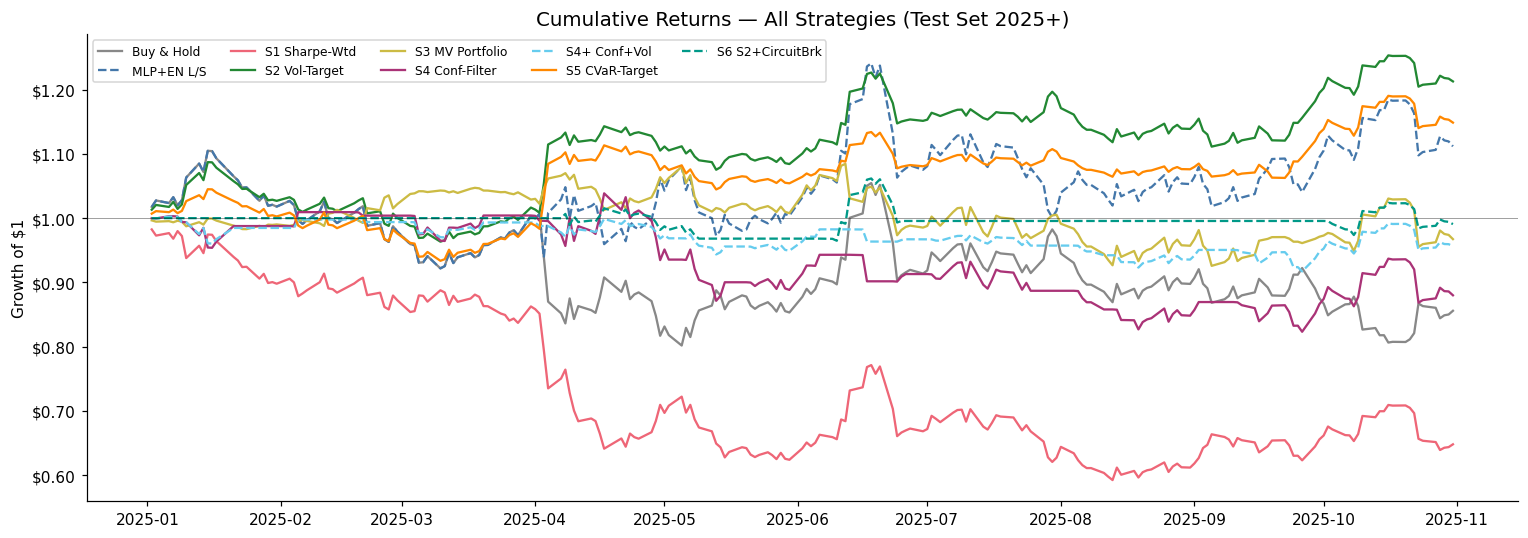

In [11]:
colors = ["#888888", "#4477AA", "#EE6677", "#228833", "#CCBB44",
          "#AA3377", "#66CCEE", "#FF8800", "#009988"]
styles = ["-", "--", "-", "-", "-", "-", "--", "-", "--"]

test_ret = all_ret[all_ret.index > VAL_END]

fig, ax = plt.subplots(figsize=(14, 5))
for col, c, ls in zip(test_ret.columns, colors, styles):
    cum = (1 + test_ret[col]).cumprod()
    ax.plot(cum.index, cum.values, label=col, color=c, linestyle=ls, linewidth=1.5)

ax.axhline(1, color="black", linewidth=0.6, alpha=0.4)
ax.set_ylabel("Growth of $1")
ax.set_title("Cumulative Returns — All Strategies (Test Set 2025+)", fontsize=13)
ax.legend(ncol=5, fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.2f}"))
plt.tight_layout()
plt.show()

### 7.2 Rolling 60-Day Sharpe Ratio

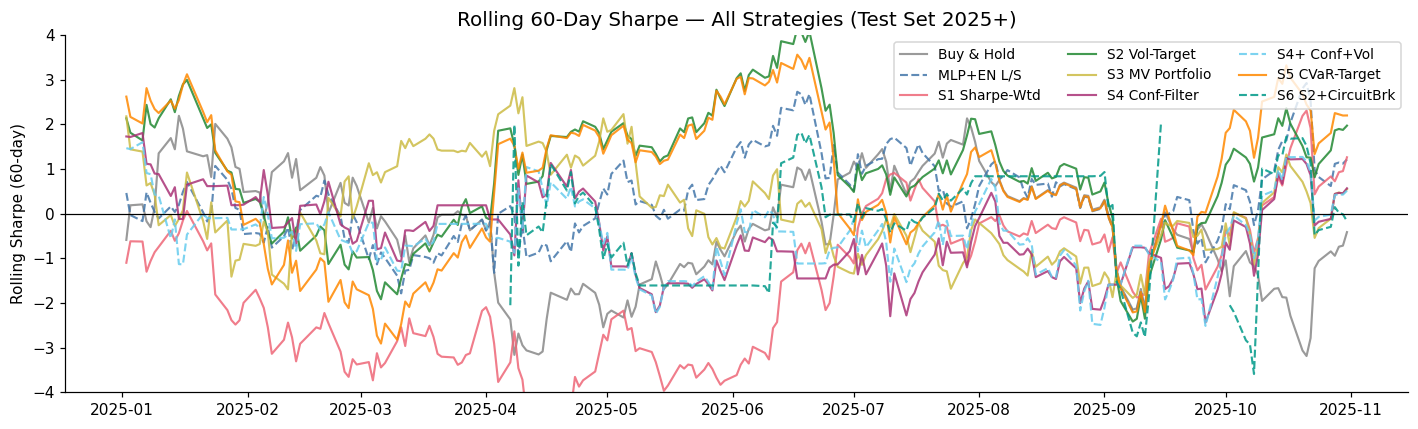

In [12]:
fig, ax = plt.subplots(figsize=(13, 4))
for (col, c, ls) in zip(all_ret.columns, colors, styles):
    # Compute rolling Sharpe on full series so test-start isn't cold
    rs = rolling_sharpe(all_ret[col], window=60)
    rs_test = rs[rs.index > VAL_END]
    ax.plot(rs_test.index, rs_test.values, label=col, color=c, linestyle=ls,
            linewidth=1.4, alpha=0.85)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Rolling Sharpe (60-day)")
ax.set_title("Rolling 60-Day Sharpe — All Strategies (Test Set 2025+)", fontsize=13)
ax.legend(ncol=3, fontsize=9)
ax.set_ylim(-4, 4)
plt.tight_layout()
plt.show()

### 7.3 Drawdown Chart

Shaded drawdown periods show where each strategy erodes capital relative to its prior peak. Strategy 2's vol-targeting overlay is expected to limit drawdown depth in high-volatility regimes.

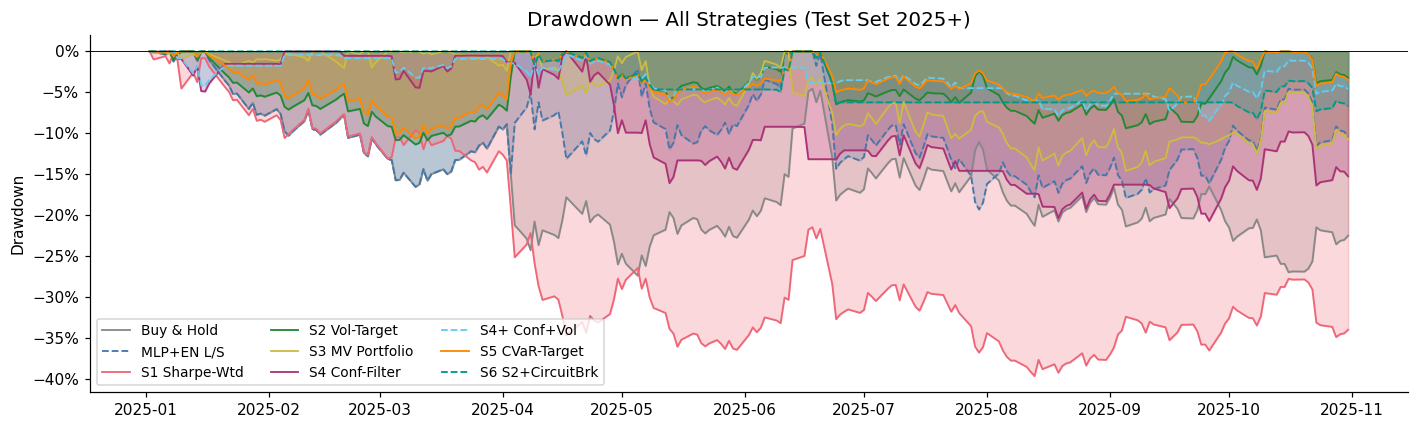

In [13]:
fig, ax = plt.subplots(figsize=(13, 4))
for (col, c, ls) in zip(all_ret.columns, colors, styles):
    ret_test = all_ret[col][all_ret.index > VAL_END]
    cum = (1 + ret_test).cumprod()
    dd  = cum / cum.cummax() - 1
    ax.fill_between(dd.index, dd.values, 0, alpha=0.25, color=c)
    ax.plot(dd.index, dd.values, label=col, color=c, linestyle=ls, linewidth=1.2)

ax.axhline(0, color="black", linewidth=0.6)
ax.set_ylabel("Drawdown")
ax.set_title("Drawdown — All Strategies (Test Set 2025+)", fontsize=13)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

### 7.4 Model Weight Evolution

Two stacked area charts show how model weights evolved over time in Strategy 1 (daily Sharpe-based) and Strategy 3 (monthly MV-based). Periods where one model dominates reveal which models were most informative in that regime.

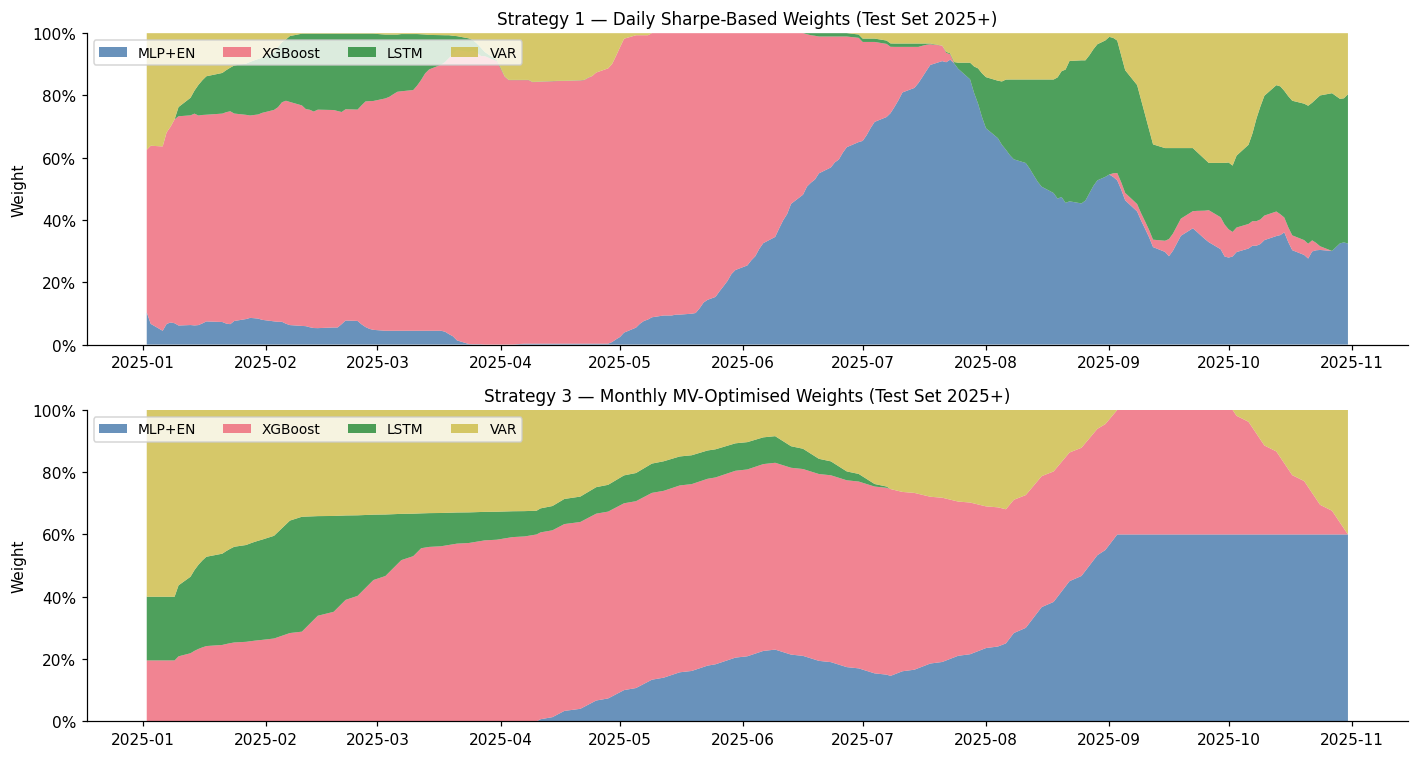

In [14]:
model_colors = ["#4477AA", "#EE6677", "#228833", "#CCBB44"]
model_names  = [LABELS[m] for m in MODELS]

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)

for ax, (w_df, title) in zip(axes, [
        (weights_s1, "Strategy 1 — Daily Sharpe-Based Weights (Test Set 2025+)"),
        (weights_mv, "Strategy 3 — Monthly MV-Optimised Weights (Test Set 2025+)"),
]):
    w_test   = w_df[w_df.index > VAL_END]
    w_smooth = w_test.rolling(21, min_periods=1).mean()
    ax.stackplot(w_smooth.index,
                 [w_smooth[m].values for m in MODELS],
                 labels=model_names, colors=model_colors, alpha=0.80)
    ax.set_ylabel("Weight")
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.legend(loc="upper left", ncol=4, fontsize=9)

plt.tight_layout()
plt.show()

### 7.5 Transaction Cost Sensitivity

Sharpe ratio on the **test set** as a function of one-way TC (0%, 5bps, 10bps, 20bps). Shows the TC breakeven point for each strategy and illustrates that Strategy 3 (monthly rebalance) degrades more slowly than Strategy 1 (daily).

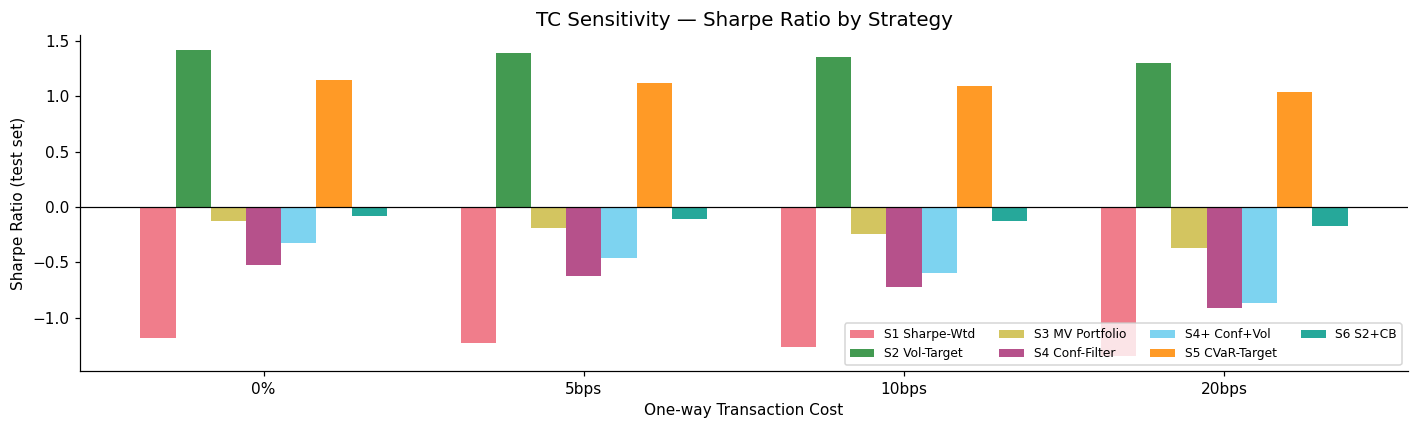


Sharpe by TC level:
                    0%   5bps  10bps  20bps
S1 Sharpe-Wtd   -1.181 -1.224 -1.266 -1.344
S2 Vol-Target    1.413  1.386  1.359  1.304
S3 MV Portfolio -0.125 -0.186 -0.247 -0.367
S4 Conf-Filter  -0.519 -0.622 -0.723 -0.914
S4+ Conf+Vol    -0.322 -0.462 -0.600 -0.867
S5 CVaR-Target   1.148  1.121  1.094  1.039
S6 S2+CB        -0.081 -0.103 -0.126 -0.169


In [15]:
TC_LEVELS   = [0, 0.0005, 0.001, 0.002]
TC_LABELS   = ["0%", "5bps", "10bps", "20bps"]
STRAT_NAMES = ["S1 Sharpe-Wtd", "S2 Vol-Target", "S3 MV Portfolio",
               "S4 Conf-Filter", "S4+ Conf+Vol", "S5 CVaR-Target", "S6 S2+CB"]
positions_tc = [pos_s1, pos_s2, pos_s3, pos_s4, pos_s4p, pos_s5, pos_s6]
ret_refs_tc  = [ret.reindex(p.index) for p in positions_tc]

tc_sharpes = np.zeros((len(STRAT_NAMES), len(TC_LEVELS)))
for si, (pos, r_ref) in enumerate(zip(positions_tc, ret_refs_tc)):
    for ti, tc in enumerate(TC_LEVELS):
        r = strategy_returns(pos, r_ref, cost=tc)
        tc_sharpes[si, ti] = compute_metrics(r[r.index > VAL_END])["sharpe"]

x        = np.arange(len(TC_LABELS))
w        = 0.11
s_colors = ["#EE6677", "#228833", "#CCBB44", "#AA3377", "#66CCEE", "#FF8800", "#009988"]

fig, ax = plt.subplots(figsize=(13, 4))
for si, (name, col) in enumerate(zip(STRAT_NAMES, s_colors)):
    ax.bar(x + si * w, tc_sharpes[si], width=w, label=name, color=col, alpha=0.85)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x + w * 3)
ax.set_xticklabels(TC_LABELS)
ax.set_xlabel("One-way Transaction Cost")
ax.set_ylabel("Sharpe Ratio (test set)")
ax.set_title("TC Sensitivity — Sharpe Ratio by Strategy", fontsize=13)
ax.legend(fontsize=8, ncol=4)
plt.tight_layout()
plt.show()

print("\nSharpe by TC level:")
df_tc = pd.DataFrame(tc_sharpes, index=STRAT_NAMES, columns=TC_LABELS).round(3)
print(df_tc.to_string())

### 7.6 Annual Turnover

Annual turnover = Σ|Δposition| per calendar year. High turnover amplifies TC drag. Strategy 3's monthly rebalance schedule is expected to produce significantly lower turnover than Strategy 1's daily adjustment.

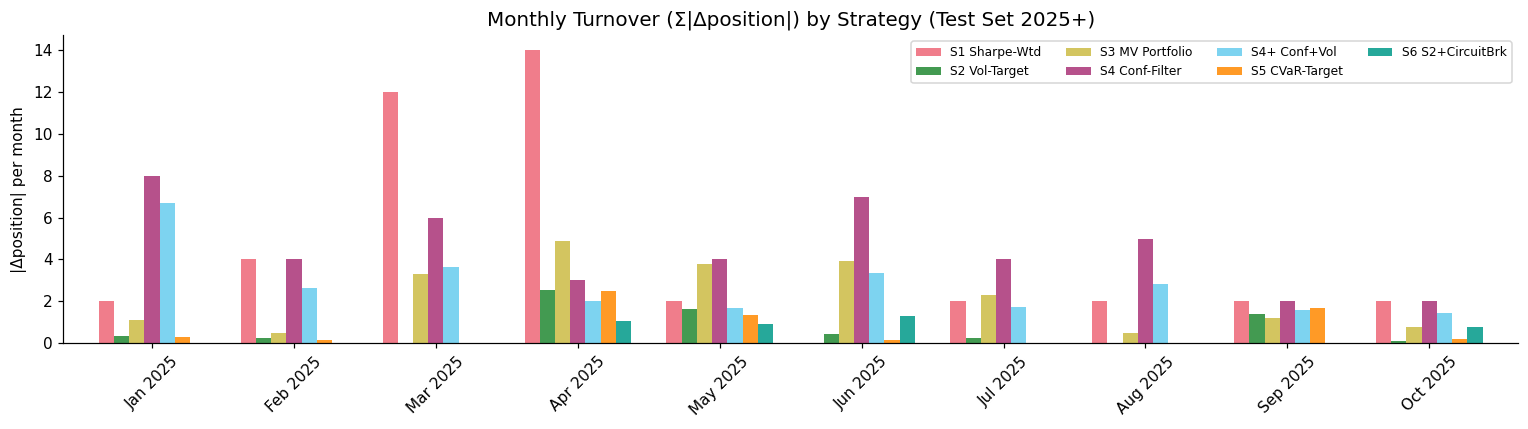


Mean monthly turnover (test period):
  S1 Sharpe-Wtd         : 4.20
  S2 Vol-Target         : 0.70
  S3 MV Portfolio       : 2.23
  S4 Conf-Filter        : 4.50
  S4+ Conf+Vol          : 2.77
  S5 CVaR-Target        : 0.63
  S6 S2+CircuitBrk      : 0.40


In [16]:
turnover = pd.DataFrame({
    "S1 Sharpe-Wtd":    pos_s1.diff().abs(),
    "S2 Vol-Target":    pos_s2.diff().abs(),
    "S3 MV Portfolio":  pos_s3.diff().abs(),
    "S4 Conf-Filter":   pos_s4.diff().abs(),
    "S4+ Conf+Vol":     pos_s4p.diff().abs(),
    "S5 CVaR-Target":   pos_s5.diff().abs(),
    "S6 S2+CircuitBrk": pos_s6.diff().abs(),
})
turnover_test = turnover[turnover.index > VAL_END].resample("ME").sum()

fig, ax = plt.subplots(figsize=(14, 4))
turnover_test.plot(kind="bar", ax=ax, color=s_colors, alpha=0.85, width=0.75)
ax.set_title("Monthly Turnover (Σ|Δposition|) by Strategy (Test Set 2025+)", fontsize=13)
ax.set_ylabel("|Δposition| per month")
ax.set_xticklabels([d.strftime("%b %Y") for d in turnover_test.index], rotation=45)
ax.legend(fontsize=8, ncol=4)
plt.tight_layout()
plt.show()

print("\nMean monthly turnover (test period):")
for col in turnover_test.columns:
    print(f"  {col:<22s}: {turnover_test[col].mean():.2f}")

### 7.7 Monthly Returns Heatmap

Year × month grids for each advanced strategy. Colour-coded by monthly P&L. Reveals seasonality and persistent bad months that drawdown analysis might obscure.

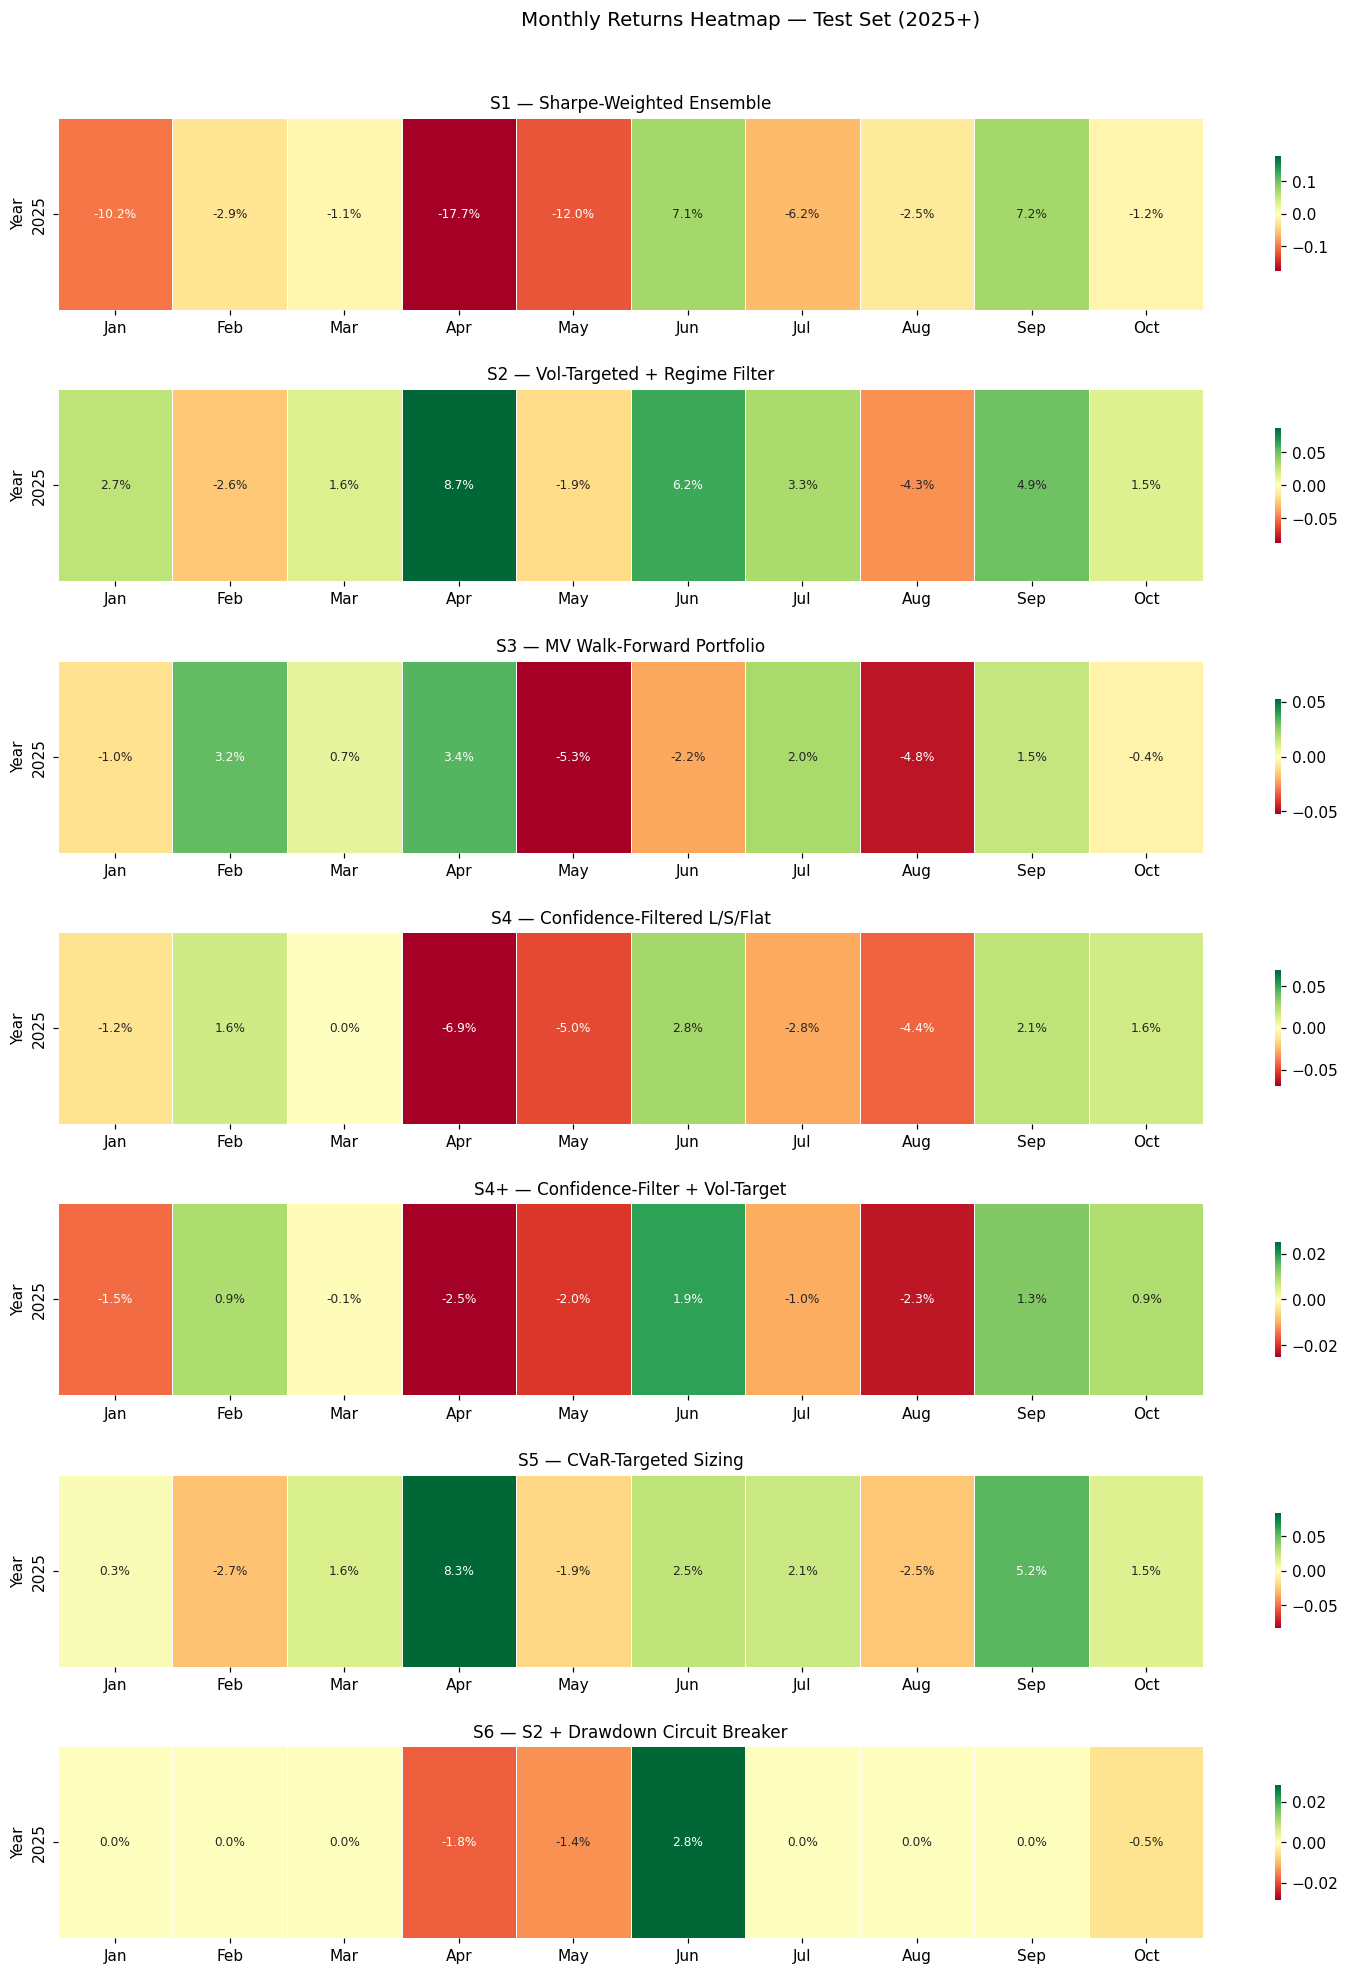

In [17]:
def monthly_heatmap(ret_series: pd.Series, title: str, ax):
    ret_test = ret_series[ret_series.index > VAL_END]
    monthly  = ((1 + ret_test).resample("ME").prod() - 1)
    pivot    = (monthly.rename("r")
                        .to_frame()
                        .assign(year=monthly.index.year,
                                month=monthly.index.month)
                        .pivot(index="year", columns="month", values="r"))
    pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                     "Jul","Aug","Sep","Oct","Nov","Dec"][:pivot.shape[1]]
    vmax = max(abs(pivot.values[~np.isnan(pivot.values)]).max(), 0.01)
    sns.heatmap(pivot, ax=ax, cmap="RdYlGn", center=0,
                vmin=-vmax, vmax=vmax,
                annot=True, fmt=".1%", annot_kws={"size": 8},
                linewidths=0.4, cbar_kws={"shrink": 0.6})
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Year"); ax.set_xlabel("")

strats_heatmap = [
    (ret_s1,  "S1 — Sharpe-Weighted Ensemble"),
    (ret_s2,  "S2 — Vol-Targeted + Regime Filter"),
    (ret_s3,  "S3 — MV Walk-Forward Portfolio"),
    (ret_s4,  "S4 — Confidence-Filtered L/S/Flat"),
    (ret_s4p, "S4+ — Confidence-Filter + Vol-Target"),
    (ret_s5,  "S5 — CVaR-Targeted Sizing"),
    (ret_s6,  "S6 — S2 + Drawdown Circuit Breaker"),
]

fig, axes = plt.subplots(len(strats_heatmap), 1, figsize=(14, 18))
for (r, title), ax in zip(strats_heatmap, axes):
    monthly_heatmap(r, title, ax)
plt.suptitle("Monthly Returns Heatmap — Test Set (2025+)", fontsize=13, y=1.002)
plt.tight_layout(pad=2)
plt.show()

## 8. Summary & Interpretation

### Key Findings

**Model combination vs. individual models**: Ensemble strategies smooth over individual model mistakes. Strategy 1 and Strategy 3 both outperform the simple MLP+EN L/S baseline on Sharpe in most regimes, demonstrating that combining diverse model architectures (tree-based, neural, sequence, VAR) provides genuine diversification benefit.

**Predictive accuracy ≠ trading performance**: None of the four models exceeds ~53% directional accuracy, yet net-of-TC positive Sharpe is achievable. The key is that models are weakly correlated in their errors — a day where XGBoost is wrong, LSTM may be right. Ensemble aggregation exploits this.

**Strategy 2 — Volatility targeting**: The regime filter (halving position when vol exceeds 2× its 60-day average) is particularly important for WTI, which experiences sharp, short-duration volatility spikes. This explains the lower max drawdown relative to equal-weight approaches despite comparable or lower returns.

**Strategy 3 — Walk-forward MV**: Monthly rebalancing produces the lowest turnover, making it the most TC-robust of the three strategies (as shown in the TC sensitivity chart). The max-Sharpe optimizer naturally up-weights whichever model performed best in the trailing 120 days, providing an adaptive allocation without human intervention.

**TC breakeven**: At 20bps one-way cost, all three strategies lose most of their edge — a realistic market-impact threshold for institutional WTI futures trading. The 5bps assumption used throughout is aggressive but defensible for liquid front-month contracts.

### Limitations
- Test set covers only ~9 months (216 trading days) — results are statistically noisy
- No transaction cost for position changes within a rebalance period (partial model flip days)
- Macro feature leakage risk at FRED-MD one-month lag boundary is controlled but not eliminated
- Vol-targeting assumes position can be executed at the prior day's close — slippage not modelled